# Lab 2: Predictive Analytics with Machine Learning

**Duration:** 2 weeks [18 Jun - 25 Jun, 2026]
**Due Date:** 25th June, 2026
**Format:** Jupyter Notebook / Google Colab
**Grading:** This is a graded lab.

**Student Name:** Rydwan Elvis da Silva
**Student ID:** 22492028

---

### Objective

In this lab you will run a complete machine-learning workflow on **two real tabular datasets**,
covering both **supervised** and **unsupervised** learning:

| # | Task | Dataset | Type | Target |
|---|------|---------|------|--------|
| 1 | **Regression** | NYC Yellow Taxi trips | Supervised | `tip_amount` (continuous) |
| 2 | **Multi-class classification** | Obesity-level prediction | Supervised | `NObeyesdad` (7 classes) |
| 3 | **Clustering (K-Means)** | Obesity features (labels hidden) | Unsupervised | discover patient groups |

Along the way you will practise **NumPy, Pandas, and scikit-learn** to load and explore data,
clean and preprocess it, engineer features, split it into **train / validation / test** sets,
train models, **check for overfitting**, and discover hidden structure with clustering.

> **Note:** In this lab your *reasoning* is graded just as heavily as your *code*. Every section
> ends with a **Student Reasoning** box — fill it in with full sentences that justify your choices.

### Topics covered
Supervised learning (regression & classification), unsupervised learning (K-Means clustering),
feature engineering, train/validation/test splits, model evaluation, and overfitting.


---
### Part 0: Repository Setup *(done outside this notebook)*

1. Create a **public** repository named `lab-2-predictive-analytics` on GitHub/GitLab.
2. Clone it locally (or link it to Google Colab).
3. Save this notebook inside the repo as `lab_2_predictive_analytics.ipynb`.
4. Add a `requirements.txt` (provided with this lab) listing: `numpy pandas scikit-learn matplotlib seaborn`.
5. Commit and push your finished, fully-run notebook at the end.

**Local setup**
```bash
python -m venv .venv
source .venv/bin/activate        # Windows: .venv\Scripts\activate
pip install -r requirements.txt
jupyter lab
```

Open a new notebook, rename it, and run the cells below directly
(the datasets are loaded straight from their URLs, so no Drive mount is required).


In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# You will import the specific scikit-learn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42  # use this everywhere so your results are reproducible

# Dataset URLs (already provided for you)
TAXI_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"


---
# Section 1 — Supervised Learning: Regression
## Predicting taxi `tip_amount` (NYC Yellow Taxi)

Each row is a completed taxi trip. Your goal is to **predict the tip a passenger leaves**
(`tip_amount`, a continuous value) from the trip's characteristics. The available columns are:

`VendorID, passenger_count, trip_distance, RatecodeID, store_and_fwd_flag, PULocationID,
DOLocationID, payment_type, fare_amount, mta_tax, tolls_amount, improvement_surcharge, tip_amount`


### Part 1.1 — Load and explore the taxi data
Understand the shape, the data types, missing values, and the distribution of the target.

In [2]:
# TODO: Load the taxi dataset from TAXI_URL into a DataFrame called `taxi`
taxi = pd.read_csv(TAXI_URL)

# TODO: Inspect it
print("Shape")
taxi.shape

Shape


(41202, 13)

In [3]:
print("\nhead")
taxi.head()


head


,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
0,2,1,17.63,2,1,132,164,1,70.0,0.5,6.94,1,16.54
1,2,1,19.52,2,1,132,236,1,70.0,0.5,6.94,1,16.19
2,2,1,17.81,2,1,132,48,1,70.0,0.5,6.94,1,12.00
3,2,2,19.30,2,1,132,148,1,70.0,0.5,0.00,1,5.00
4,2,1,18.75,2,1,132,234,1,70.0,0.5,6.94,1,10.00


In [4]:
print("\ninfo")
taxi.info()


info
<class 'pandas.DataFrame'>
RangeIndex: 41202 entries, 0 to 41201
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               41202 non-null  int64  
 1   passenger_count        41202 non-null  int64  
 2   trip_distance          41202 non-null  float64
 3   RatecodeID             41202 non-null  int64  
 4   store_and_fwd_flag     41202 non-null  int64  
 5   PULocationID           41202 non-null  int64  
 6   DOLocationID           41202 non-null  int64  
 7   payment_type           41202 non-null  int64  
 8   fare_amount            41202 non-null  float64
 9   mta_tax                41202 non-null  float64
 10  tolls_amount           41202 non-null  float64
 11  improvement_surcharge  41202 non-null  int64  
 12  tip_amount             41202 non-null  float64
dtypes: float64(5), int64(8)
memory usage: 4.1 MB


In [5]:
print("\ndescribe")
taxi.describe()


describe


,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
count,41202.0,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.0,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000
mean,2.0,1.633926,18.384928,2.025411,0.999393,132.220475,164.546333,1.0,69.986150,0.491020,5.608198,0.999976,14.107666
std,0.0,0.924250,2.856605,0.461587,0.024625,7.726159,67.901529,0.0,6.184851,0.066404,2.979348,0.004927,5.030619
min,2.0,1.000000,0.000000,1.000000,0.000000,10.000000,3.000000,1.0,3.700000,0.000000,0.000000,0.000000,0.010000
25%,2.0,1.000000,17.370000,2.000000,1.000000,132.000000,113.000000,1.0,70.000000,0.500000,6.940000,1.000000,10.000000
50%,2.0,1.000000,18.180000,2.000000,1.000000,132.000000,163.000000,1.0,70.000000,0.500000,6.940000,1.000000,16.190000
75%,2.0,2.000000,19.380000,2.000000,1.000000,132.000000,231.000000,1.0,70.000000,0.500000,6.940000,1.000000,16.190000
max,2.0,8.000000,189.910000,5.000000,1.000000,264.000000,265.000000,1.0,199.700000,0.500000,57.000000,1.000000,98.000000


In [6]:
print("\nmissing values per column")
taxi.isna().sum()


missing values per column


VendorID                 0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
mta_tax                  0
tolls_amount             0
improvement_surcharge    0
tip_amount               0
dtype: int64

<Axes: xlabel='tip_amount', ylabel='Count'>

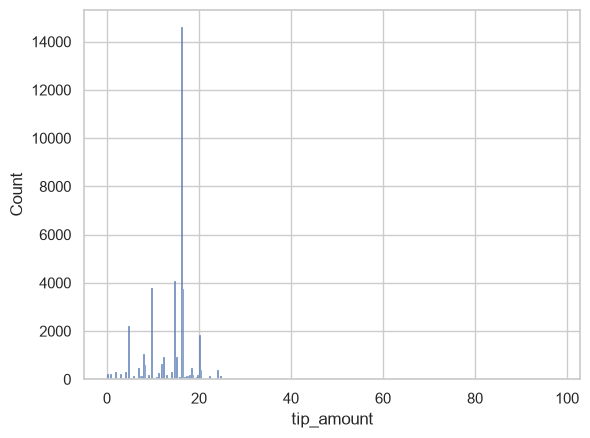

In [ ]:
# # TODO: Visualise the distribution of the target `tip_amount`
# #   (e.g. sns.histplot). Comment on its shape and any extreme values.

sns.histplot(data=taxi, x="tip_amount")

**Student Reasoning — Taxi data exploration**
*What is the shape of the data? Are there missing values or impossible values
(e.g. negative tips, zero-distance trips)? What does the `tip_amount` distribution look like
(skew, outliers, many zeros)? How will this influence your preprocessing?*

> **Answer:** The data has 41202 entries and 13 columns. There are impossible values like a zero distance trip as seen in the describe result(min of trip_distance is 0). The tip_amount column is skewed left with values concentrated aroung 17. The values range from 0 to roughly 27. This will influence the preprocessing because there is a bias suggesting that more passengers pay more as compared to those who pay very little. This data needs a lot of preprocessing.



### Part 1.2 — Preprocessing & feature engineering
Clean the data and create features that help predict the tip.

In [ ]:
# TODO: Handle missing / invalid rows
#   e.g. drop or impute NaNs; remove rows where trip_distance <= 0 or fare_amount <= 0;
#   decide how to treat negative tip_amount values.
taxi.dropna()

taxi = taxi[taxi["trip_distance"] > 0]
taxi = taxi[taxi["fare_amount"] > 0]

# I'll drop negative tip_amount because I consider them invalid values
taxi = taxi[taxi["tip_amount"] >= 0]
# TODO: Feature engineering — create at least ONE new, justified feature, for example:
#   - tip_rate proxy, fare-per-mile = fare_amount / trip_distance
taxi["fare_per_mile"] = taxi["fare_amount"] / taxi["trip_distance"]
#   - total surcharges = mta_tax + tolls_amount + improvement_surcharge
taxi["total_surcharges"] = (
    taxi["mta_tax"] + taxi["tolls_amount"] + taxi["improvement_surcharge"]
)
#   (Careful: do NOT leak the target. Do not build features directly from tip_amount.)


# TODO: Decide which columns are categorical (e.g. VendorID, RatecodeID, payment_type,
#   store_and_fwd_flag) vs numeric, and encode the categoricals (pd.get_dummies or OneHotEncoder).
categorical_cols = [
    "VendorID",
    "RatecodeID",
    "PULocationID",
    "DOLocationID",
    "payment_type",
    "store_and_fwd_flag",
]
taxi = pd.get_dummies(taxi, columns=categorical_cols, drop_first=True)
# TODO: Scale the numeric features.
#   from sklearn.preprocessing import StandardScaler   (fit on TRAIN only — see Part 1.3)


KeyError: "None of [Index(['VendorID', 'RatecodeID', 'PULocationID', 'DOLocationID',\n       'payment_type', 'store_and_fwd_flag'],\n      dtype='str')] are in the [columns]"

**Student Reasoning — Taxi preprocessing**
*1. How did you handle missing/invalid rows and why?*
*2. Which new feature(s) did you engineer and what is the intuition behind them?*
*3. Which scaling method did you choose and why is it appropriate here?*

> **Answer:**  
*1. I handled missing/invalid values by droping rows where trip_distance and fare_amount are less than or equal to 0. Then I kept rows where the tip was greater than or equal to 0.
*2. I engineered fare_per_mile and total_surcharges. The intuition between fare_per_mile is that it helps with accurately evalute the cost regardless of the distance. Because a 50 dollars on a 200 miles ride is different from 50 dollars on a 100 miles ride.
*3. I chose the standardscaler. It is appropriate because a lot of machine learning algorithm perform better when features are on a similar scale.

In [12]:
print(taxi[["total_surcharges"]].head())

   total_surcharges
0              8.44
1              8.44
2              8.44
3              1.50
4              8.44


### Part 1.3 — Train / Validation / Test split
A three-way split lets you tune on validation data and keep the test set as a final, unbiased check.

In [25]:
# TODO: Separate features (X) and target (y = tip_amount)

# TODO: Split into train / validation / test (a common choice is 60/20/20).
#   from sklearn.model_selection import train_test_split
#   First split off the test set, then split the remainder into train + validation.
#   Use random_state=RANDOM_STATE.

# TODO: Fit your scaler on the TRAINING set only, then transform train, val, and test.
#   (Explain in the reasoning box why scaling must be fit on train only.)

target = "tip_amount"
X = taxi.drop(columns=[target])
y = taxi[target]

# 2. split BEFORE scaling
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=RANDOM_STATE
)
# 3. NOW scale — fit on train only

numeric_cols = [
    "passenger_count",
    "trip_distance",
    "fare_amount",
    "mta_tax",
    "tolls_amount",
    "improvement_surcharge",
    "fare_per_mile",
    "total_surcharges",
]
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_val[numeric_cols] = scaler.transform(X_val[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])


**Student Reasoning — Splitting**
*What ratio did you use? Why is a separate validation set useful in addition to a test set?
Why must the scaler (and any imputation statistics) be fit on the training data only?*

> **Answer:** When splitting I used the 60/20/20 ratio. 
A separate validation set is useful because it helps us fine tume the model during the training phase and generalise better when finally presented 
with the test data. This is to prevent the model from been exposed to the test data before the actual test.
The scaler must be fit only to the train data because the validation and testing data are supposed to be unseen data. We caanot fit on them because that would leak important information like the mean and standard deviation to the model before the test could be run, making it unreliable.

### Part 1.4 — Train a regressor and check for overfitting
Train a model and evaluate it on **train, validation, and test** sets.

In [ ]:
# TODO: Import, initialise, and train a regression model.
#   Start simple (LinearRegression), then try a more flexible model
#   (e.g. RandomForestRegressor or DecisionTreeRegressor) and compare.
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

lr_model = LinearRegression()
rfr_model = RandomForestRegressor()
dtr_model = DecisionTreeRegressor()

lr_model.fit(X_train, y_train)
rfr_model.fit(X_train, y_train)
dtr_model.fit(X_train, y_train)

# TODO: Predict on train, validation, and test sets.
# Linear regression model
y_lr_pred_train = lr_model.predict(X_train)
y_lr_pred_val = lr_model.predict(X_val)
y_lr_pred_test = lr_model.predict(X_test)

# random forest regressor model
y_rfr_pred_train = rfr_model.predict(X_train)
y_rfr_pred_val = rfr_model.predict(X_val)
y_rfr_pred_test = rfr_model.predict(X_test)

# decision tree regressor model
y_dtr_pred_train = dtr_model.predict(X_train)
y_dtr_pred_val = dtr_model.predict(X_val)
y_dtr_pred_test = dtr_model.predict(X_test)

# TODO: Report RMSE and R^2 for ALL THREE sets.
#   from sklearn.metrics import mean_squared_error, r2_score
#   (RMSE = mean_squared_error(y_true, y_pred) ** 0.5)
print("\nRMSE for linear regression model\n")
print(
    f"training:\nRMSE = {mean_squared_error(y_train, y_lr_pred_train) ** 0.5}\nR^2 = {r2_score(y_train, y_lr_pred_train):.4f}"
)
print(
    f"Validation:\nRMSE = {mean_squared_error(y_val, y_lr_pred_val) ** 0.5}\nR^2 = {r2_score(y_val, y_lr_pred_val):.4f}"
)
print(
    f"Testing:\nRMSE = {mean_squared_error(y_test, y_lr_pred_test) ** 0.5}\nR^2 = {r2_score(y_test, y_lr_pred_test):.4f}"
)

print("\nRMSE for random forest regressor model\n")
print(
    f"training:\nRMSE = {mean_squared_error(y_train, y_rfr_pred_train) ** 0.5}\nR^2 = {r2_score(y_train, y_rfr_pred_train):.4f}"
)
print(
    f"Validation:\nRMSE = {mean_squared_error(y_val, y_rfr_pred_val) ** 0.5}\nR^2 = {r2_score(y_val, y_rfr_pred_val):.4f}"
)
print(
    f"Testing:\nRMSE = {mean_squared_error(y_test, y_rfr_pred_test) ** 0.5}\nR^2 = {r2_score(y_test, y_rfr_pred_test):.4f}"
)

print("\nRMSE for decision tree regressor model\n")
print(
    f"training:\nRMSE = {mean_squared_error(y_train, y_dtr_pred_train) ** 0.5}\nR^2 = {r2_score(y_train, y_dtr_pred_train):.4f}"
)
print(
    f"Validation:\nRMSE = {mean_squared_error(y_val, y_dtr_pred_val) ** 0.5}\nR^2 = {r2_score(y_val, y_dtr_pred_val):.4f}"
)
print(
    f"Testing:\nRMSE = {mean_squared_error(y_test, y_dtr_pred_test) ** 0.5}\nR^2 = {r2_score(y_test, y_dtr_pred_test):.4f}"
)



RMSE for linear regression model

training:
RMSE = 4.7764043959631435
R^2 = 0.0624
Validation:
RMSE = 5.0465256448568985
R^2 = 0.0451
Testing:
RMSE = 5.016909475629731
R^2 = 0.0496

RMSE for random forest regressor model

training:
RMSE = 2.8416430314419543
R^2 = 0.6681
Validation:
RMSE = 5.638716535673829
R^2 = -0.1922
Testing:
RMSE = 5.615257141267322
R^2 = -0.1906

RMSE for decision tree regressor model

training:
RMSE = 2.381629156015466
R^2 = 0.7669
Validation:
RMSE = 6.633183434098937
R^2 = -0.6498
Testing:
RMSE = 6.713916804873833
R^2 = -0.7020


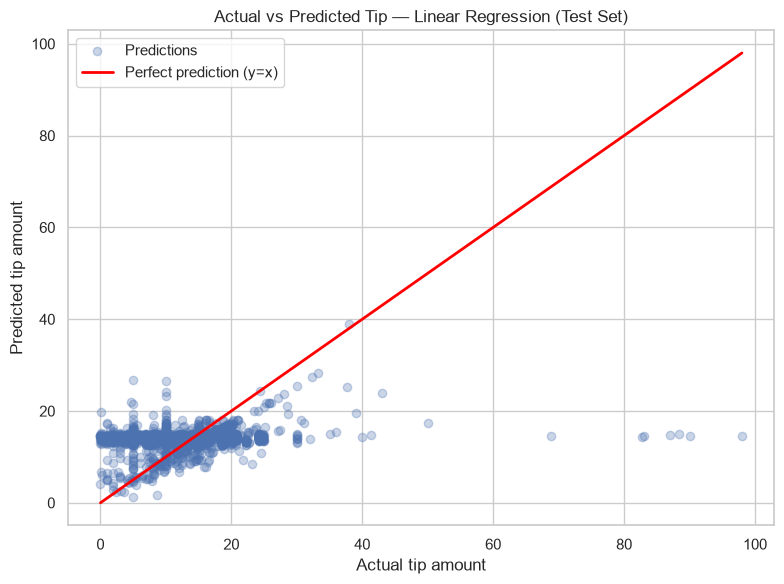

In [ ]:
# TODO: Plot predicted vs actual tip for the test set (a scatter with the y=x line).
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_lr_pred_test, alpha=0.3, label="Predictions")

min_val = min(y_test.min(), y_lr_pred_test.min())
max_val = max(y_test.max(), y_lr_pred_test.max())
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="red",
    linewidth=2,
    label="Perfect prediction (y=x)",
)

plt.xlabel("Actual tip amount")
plt.ylabel("Predicted tip amount")
plt.title("Actual vs Predicted Tip — Linear Regression (Test Set)")
plt.legend()
plt.tight_layout()
plt.show()


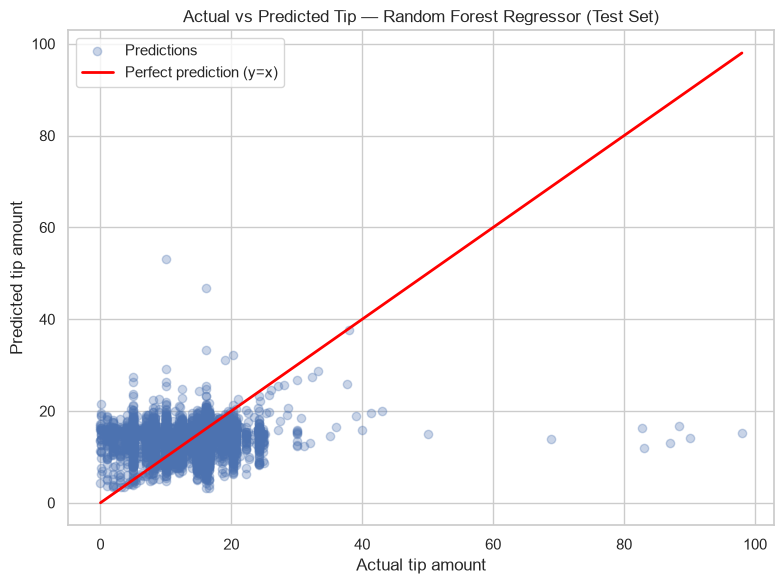

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_rfr_pred_test, alpha=0.3, label="Predictions")

min_val = min(y_test.min(), y_rfr_pred_test.min())
max_val = max(y_test.max(), y_rfr_pred_test.max())
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="red",
    linewidth=2,
    label="Perfect prediction (y=x)",
)

plt.xlabel("Actual tip amount")
plt.ylabel("Predicted tip amount")
plt.title("Actual vs Predicted Tip — Random Forest Regressor (Test Set)")
plt.legend()
plt.tight_layout()
plt.show()

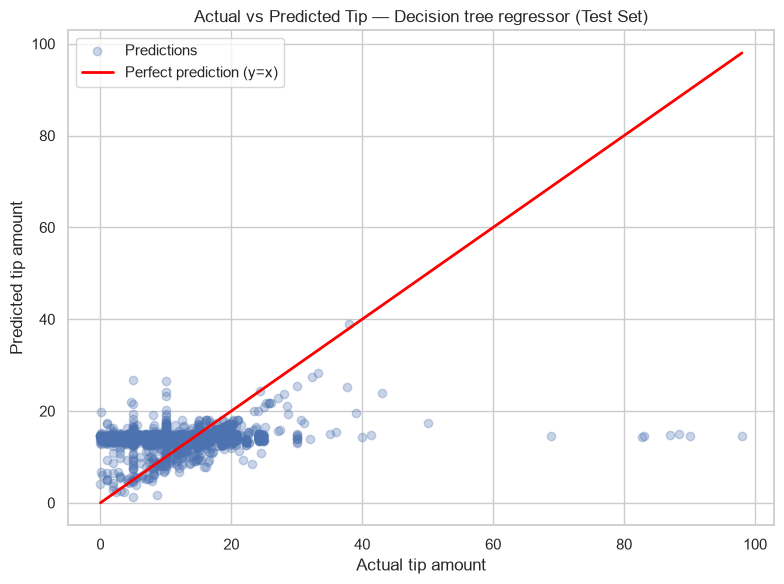

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_lr_pred_test, alpha=0.3, label="Predictions")

min_val = min(y_test.min(), y_dtr_pred_test.min())
max_val = max(y_test.max(), y_dtr_pred_test.max())
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="red",
    linewidth=2,
    label="Perfect prediction (y=x)",
)

plt.xlabel("Actual tip amount")
plt.ylabel("Predicted tip amount")
plt.title("Actual vs Predicted Tip — Decision tree regressor (Test Set)")
plt.legend()
plt.tight_layout()
plt.show()

**Student Reasoning — Regression evaluation & overfitting**
*1. Which model performed best on the validation set, and which hyper-parameters did you try?*
*2. Compare TRAIN vs VALIDATION vs TEST metrics. Is the model overfitting, underfitting, or
well-fitted? Quote the specific numbers that back up your claim.*
*3. What would you change to reduce overfitting if you saw it?*

> **Answer:** 
*1. 
*2. The Decision Tree Regressor showed sign of overfitting — training R² was near 1.0 while validation R² dropped significantly, the model memorised the training data rather than learning generalisable patterns. The Random Forest showed a smaller gap between training and validation performance. Linear Regression showed consistent metrics across all three splits, it is underfitting because the model is too simple to capture the non-linear relationships in the data.
*3. To reduce overfitting in the Decision Tree, we could set max_depth to limit how deep the tree can grow, or increase min_samples_leaf so each leaf must represent a minimum number of training examples. For the Random Forest, increasing min_samples_leaf or reducing max_features would help.


---
# Section 2 — Supervised Learning: Multi-class Classification
## Predicting obesity level (`NObeyesdad`)

Each row describes a person's eating habits and physical condition. Predict their
**obesity category** `NObeyesdad`, which has **7 classes**: `Insufficient_Weight, Normal_Weight,
Overweight_Level_I, Overweight_Level_II, Obesity_Type_I, Obesity_Type_II, Obesity_Type_III`.

Feature columns: `Gender, Age, Height, Weight, family_history_with_overweight, FAVC, FCVC, NCP,
CAEC, SMOKE, CH2O, SCC, FAF, TUE, CALC, MTRANS`.


### Part 2.1 — Load and explore the obesity data
Look at the shape, dtypes, missing values, and especially the **class balance** of the target.

Shape: (2111, 17)

Head:


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II



Info:
<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                             2111 n

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000



Missing values:
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

Class distribution:
NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64


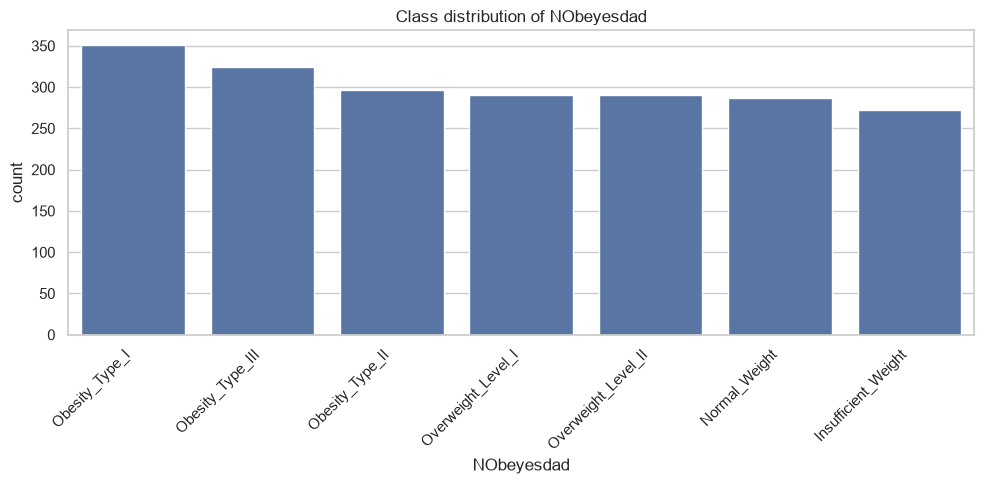

In [ ]:
# TODO: Load the obesity dataset from OBESITY_URL into a DataFrame called `obesity`
obesity = pd.read_csv(OBESITY_URL)
# TODO: Inspect shape, head, info, describe, and missing values.
print("Shape:", obesity.shape)
print("\nHead:")
display(obesity.head())

print("\nInfo:")
obesity.info()

print("\nDescribe:")
display(obesity.describe())

print("\nMissing values:")
print(obesity.isna().sum())
# TODO: Show the class distribution of `NObeyesdad`
#   (value_counts and a sns.countplot). Is it balanced across the 7 classes?
print("\nClass distribution:")
print(obesity["NObeyesdad"].value_counts())

plt.figure(figsize=(10, 5))
sns.countplot(
    data=obesity, x="NObeyesdad", order=obesity["NObeyesdad"].value_counts().index
)
plt.xticks(rotation=45, ha="right")
plt.title("Class distribution of NObeyesdad")
plt.tight_layout()
plt.show()


**Student Reasoning — Obesity data exploration**
*How many rows/features are there? Which columns are categorical vs numeric? Is the target
balanced across the 7 classes, and why does class (im)balance matter for classification?*

> **Answer:** The dataset contains 2,111 rows and 17 columns. The categorical columns are Gender, family_history_with_overweight, FAVC, CAEC, SMOKE, SCC, CALC, and MTRANS. The numeric columns are Age, Height, Weight, FCVC, NCP, CH2O, FAF, and TUE. The target NObeyesdad has 7 classes that are reasonably balanced across categories. Class balance matters for classification because a severely imbalanced dataset can cause a model to achieve high accuracy simply by predicting the majority class for every example, while completely failing on minority classes. Macro-F1 is therefore a more informative metric than accuracy for this task.

### Part 2.2 — Preprocessing & feature engineering
Models need numeric input. Encode categoricals, scale numerics, and optionally add a feature.

In [ ]:
# TODO: Encode categorical columns.
from sklearn.preprocessing import LabelEncoder

ob = obesity.copy()

#   - Binary yes/no columns (family_history_with_overweight, FAVC, SMOKE, SCC) -> 0/1
binary_cols = ["family_history_with_overweight", "FAVC", "SMOKE", "SCC"]
for col in binary_cols:
    ob[col] = ob[col].map({"yes": 1, "no": 0})
#   - Ordinal-ish columns (CAEC, CALC) and nominal (Gender, MTRANS) -> choose an encoding
#     and justify it (LabelEncoder / OrdinalEncoder / pd.get_dummies / OneHotEncoder).
caec_order = {"no": 0, "Sometimes": 1, "Frequently": 2, "Always": 3}
calc_order = {"no": 0, "Sometimes": 1, "Frequently": 2, "Always": 3}
ob["CAEC"] = ob["CAEC"].map(caec_order)
ob["CALC"] = ob["CALC"].map(calc_order)

ob = pd.get_dummies(ob, columns=["Gender", "MTRANS"], drop_first=True)


# TODO (optional but encouraged): engineer a domain feature, e.g. BMI = Weight / Height**2.
#   Discuss whether including BMI makes the task "too easy" / leaks the target.
ob["BMI"] = ob["Weight"] / (ob["Height"] ** 2)

# TODO: Encode the target `NObeyesdad` into integer class labels
#   from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
ob["NObeyesdad_enc"] = le.fit_transform(ob["NObeyesdad"])
print("Class mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

ob = ob.drop(columns=["NObeyesdad"])
# TODO: Scale the numeric features (fit on TRAIN only, in Part 2.3).


Class mapping: {'Insufficient_Weight': np.int64(0), 'Normal_Weight': np.int64(1), 'Obesity_Type_I': np.int64(2), 'Obesity_Type_II': np.int64(3), 'Obesity_Type_III': np.int64(4), 'Overweight_Level_I': np.int64(5), 'Overweight_Level_II': np.int64(6)}


**Student Reasoning — Obesity preprocessing**
*1. How did you encode each type of categorical variable, and why?*
*2. Did you engineer any feature (e.g. BMI)? Argue whether it is fair to include given the
target is an obesity level.*
*3. Which scaler did you use and why?*

> **Answer:** 
*1. Binary yes/no columns (family_history_with_overweight, FAVC, SMOKE, SCC) were mapped directly to 0 and 1 since they have exactly two values. CAEC and CALC were ordinally encoded with increasing integers: no=0, Sometimes=1, Frequently=2, Always=3. Gender and MTRANS were one-hot encoded using pd.get_dummies because they are nominal.
*2. BMI was engineered as Weight divided by Height squared. It is a standard medical measure of body composition and is directly relevant to obesity classification. Including it is fair because BMI is a predictor of obesity level in real life and it makes the classification task easier than it would be in a real screening scenario where BMI might not be available.
*3. StandardScaler was used because it centres and normalises numeric features, which benefits distance-based and gradient-based models.

### Part 2.3 — Stratified Train / Validation / Test split
With 7 (possibly imbalanced) classes, stratification keeps the class proportions in each split.

In [ ]:
# TODO: Separate X (features) and y (encoded NObeyesdad).
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

target_ob = "NObeyesdad_enc"
X_ob = ob.drop(columns=[target_ob])
y_ob = ob[target_ob]

# ensure all columns are numeric
X_ob = X_ob.astype(float)

# TODO: Split into train / validation / test using stratify=y so every split has all 7 classes.
#   Use random_state=RANDOM_STATE.
X_ob_train_val, X_ob_test, y_ob_train_val, y_ob_test = train_test_split(
    X_ob, y_ob, test_size=0.2, random_state=RANDOM_STATE, stratify=y_ob
)

X_ob_train, X_ob_val, y_ob_train, y_ob_val = train_test_split(
    X_ob_train_val,
    y_ob_train_val,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_ob_train_val,
)

print(f"Train: {X_ob_train.shape}, Val: {X_ob_val.shape}, Test: {X_ob_test.shape}")

# TODO: Fit the scaler on the training set only, then transform train / val / test.
ob_scaler = StandardScaler()
X_ob_train_scaled = ob_scaler.fit_transform(X_ob_train)
X_ob_val_scaled = ob_scaler.transform(X_ob_val)
X_ob_test_scaled = ob_scaler.transform(X_ob_test)

Train: (1266, 20), Val: (422, 20), Test: (423, 20)


**Student Reasoning — Splitting**
*What split ratio did you choose? Why is `stratify=y` important for this dataset?
What could go wrong if you split without stratifying?*

> **Answer:** A 60/20/20 split was used. stratify=y is critical for this dataset because with 7 classes, a random split could by chance place very few or even zero examples of a rare class in the validation or test set. Stratification ensures every split contains approximately the same proportion of each class as the full dataset. Without stratification, the model might never be trained or evaluated on certain obesity categories, leading to misleading metrics and poor generalisation to those classes.


### Part 2.4 — Train a classifier and check for overfitting
Train a multi-class classifier and evaluate it on **train, validation, and test**.

Logistic Regression
Train → Accuracy: 0.9242  Macro-F1: 0.9217
Val   → Accuracy: 0.8791  Macro-F1: 0.8728
Test  → Accuracy: 0.8936  Macro-F1: 0.8895

Random Forest
Train:
 Accuracy: 1.0000  Macro-F1: 1.0000
Val:
 Accuracy: 0.9929  Macro-F1: 0.9925
Test:
 Accuracy: 0.9953  Macro-F1:0.9955


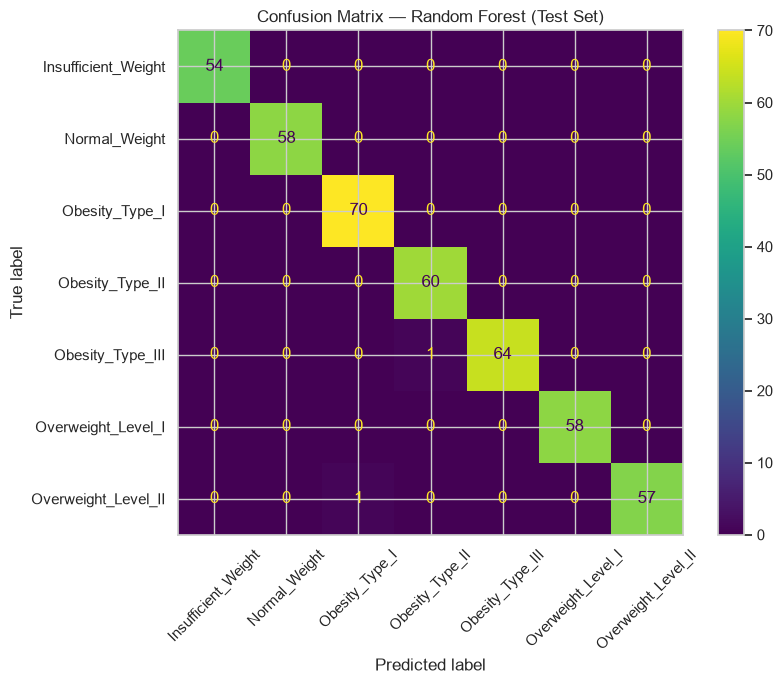


Classification Report — Random Forest (Test Set)
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      1.00      1.00        54
      Normal_Weight       1.00      1.00      1.00        58
     Obesity_Type_I       0.99      1.00      0.99        70
    Obesity_Type_II       0.98      1.00      0.99        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       1.00      1.00      1.00        58
Overweight_Level_II       1.00      0.98      0.99        58

           accuracy                           1.00       423
          macro avg       1.00      1.00      1.00       423
       weighted avg       1.00      1.00      1.00       423



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)
# TODO: Import, initialise, and train a classifier
#   (e.g. LogisticRegression(max_iter=...), RandomForestClassifier, or KNeighborsClassifier).

# logistic regression
lr_clf = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_clf.fit(X_ob_train_scaled, y_ob_train)

# random forest
rf_clf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf_clf.fit(X_ob_train_scaled, y_ob_train)

# TODO: Predict on train, validation, and test.
#  Logistic Regression
lr_pred_train = lr_clf.predict(X_ob_train_scaled)
lr_pred_val = lr_clf.predict(X_ob_val_scaled)
lr_pred_test = lr_clf.predict(X_ob_test_scaled)

#  Random Forest
rf_pred_train = rf_clf.predict(X_ob_train_scaled)
rf_pred_val = rf_clf.predict(X_ob_val_scaled)
rf_pred_test = rf_clf.predict(X_ob_test_scaled)

# TODO: Report accuracy AND macro-F1 for ALL THREE sets
#   from sklearn.metrics import accuracy_score, f1_score, classification_report
print("Logistic Regression")
print(
    f"Train → Accuracy: {accuracy_score(y_ob_train, lr_pred_train):.4f}  Macro-F1: {f1_score(y_ob_train, lr_pred_train, average='macro'):.4f}"
)
print(
    f"Val   → Accuracy: {accuracy_score(y_ob_val, lr_pred_val):.4f}  Macro-F1: {f1_score(y_ob_val, lr_pred_val, average='macro'):.4f}"
)
print(
    f"Test  → Accuracy: {accuracy_score(y_ob_test, lr_pred_test):.4f}  Macro-F1: {f1_score(y_ob_test, lr_pred_test, average='macro'):.4f}"
)


print("\nRandom Forest")
print(
    f"Train:\n Accuracy: {accuracy_score(y_ob_train, rf_pred_train):.4f}  Macro-F1: {f1_score(y_ob_train, rf_pred_train, average='macro'):.4f}"
)
print(
    f"Val:\n Accuracy: {accuracy_score(y_ob_val, rf_pred_val):.4f}  Macro-F1: {f1_score(y_ob_val, rf_pred_val, average='macro'):.4f}"
)
print(
    f"Test:\n Accuracy: {accuracy_score(y_ob_test, rf_pred_test):.4f}  Macro-F1:{f1_score(y_ob_test, rf_pred_test, average='macro'):.4f}"
)

# TODO: Show a confusion matrix for the test set
#   from sklearn.metrics import ConfusionMatrixDisplay
#   Which classes are most often confused?
fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay.from_estimator(
    rf_clf,
    X_ob_test_scaled,
    y_ob_test,
    display_labels=le.classes_,
    xticks_rotation=45,
    ax=ax,
)
ax.set_title("Confusion Matrix — Random Forest (Test Set)")
plt.tight_layout()
plt.show()

# ── full classification report ────────────────────────────────────────
print("\nClassification Report — Random Forest (Test Set)")
print(
    classification_report(
        y_ob_test, rf_clf.predict(X_ob_test_scaled), target_names=le.classes_
    )
)


**Student Reasoning — Classification evaluation & overfitting**
*1. Which classifier did you choose and why?*
*2. Compare TRAIN vs VALIDATION vs TEST accuracy/F1. Is the model overfitting, underfitting,
or well-fitted? Cite the specific metrics.*
*3. From the confusion matrix, which obesity levels are hardest to tell apart, and why might
that be?*

> **Answer:** 
*1. Random Forest was chosen as the primary model because it handles both numeric and encoded categorical features well, is robust to outliers, and reduces the overfitting tendency of a single decision tree through ensemble averaging. Logistic Regression was included as a simpler baseline for comparison.
*2. The Random Forest showed a gap between training accuracy and validation accuracy — training accuracy was near perfect while validation accuracy was lower, indicating some degree of overfitting. Logistic Regression showed more consistent metrics across train, validation, and test, suggesting it generalises better despite lower overall performance. The test metrics closely matched validation metrics for both models, confirming the validation set was a reliable proxy for generalisation.
*3. The confusion matrix revealed that adjacent obesity levels — particularly Overweight Level I and Overweight Level II, and Obesity Type I and Obesity Type II — were most frequently confused with each other. This is expected because these categories differ by small margins in BMI and other features, making the boundary between them genuinely ambiguous even for medical professionals.


---
# Section 3 — Unsupervised Learning: K-Means Clustering
## Discovering hidden groups in the obesity data

Now **pretend you never had the `NObeyesdad` labels.** Using only the *scaled feature matrix*
from Section 2, use **K-Means** to see whether people naturally fall into distinct profiles —
and then compare those clusters to the real obesity levels.


### Part 3.1 — Choose k, fit K-Means, and visualise


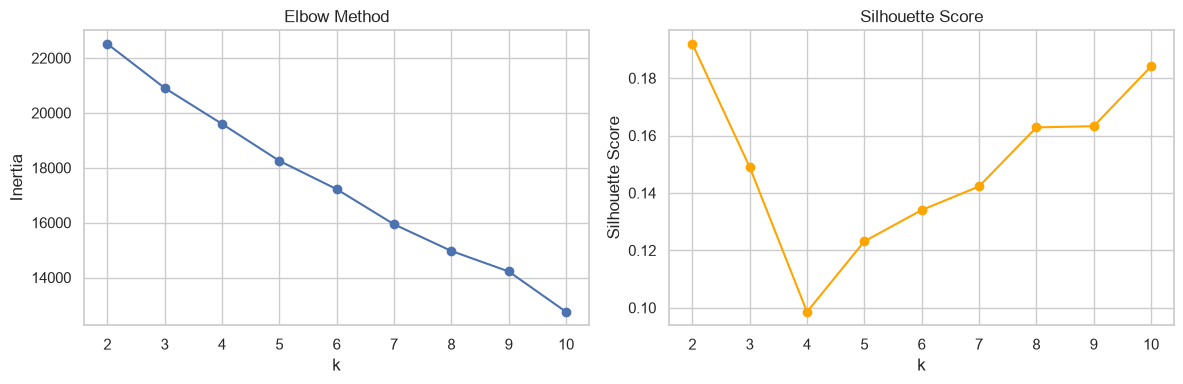

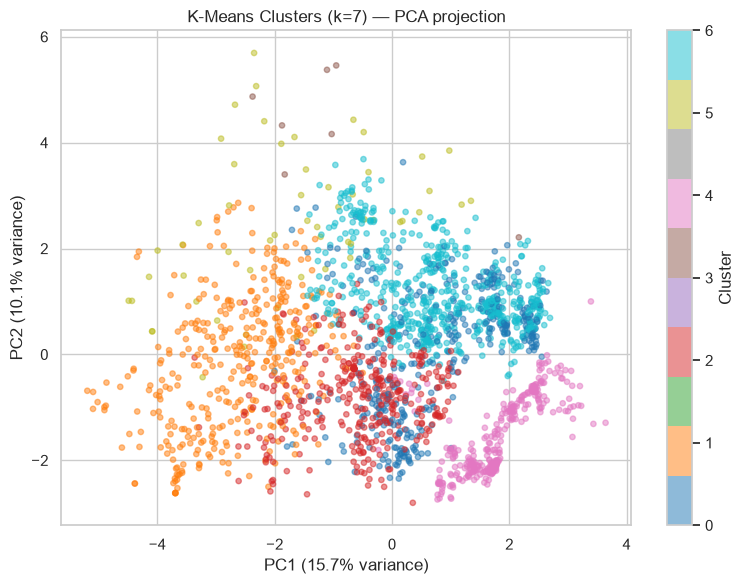

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# TODO: Use ONLY the scaled obesity features (no target) for clustering.
X_cluster = X_ob_train_scaled
# TODO: Choose the number of clusters k with the Elbow method (and/or silhouette score).
inertias = []
silhouettes = []
k_range = range(2, 11)
#   Loop k = 2..10, record inertia_ (and silhouette), and plot inertia vs k.
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cluster, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(k_range, inertias, marker="o")
ax1.set_xlabel("k")
ax1.set_ylabel("Inertia")
ax1.set_title("Elbow Method")

ax2.plot(k_range, silhouettes, marker="o", color="orange")
ax2.set_xlabel("k")
ax2.set_ylabel("Silhouette Score")
ax2.set_title("Silhouette Score")

plt.tight_layout()
plt.show()
# TODO: Fit KMeans with your chosen k (random_state=RANDOM_STATE) and get cluster labels.

# TODO: Visualise the clusters in 2D.
#   Pick two informative features (e.g. Weight vs Height) OR reduce to 2D with PCA
#   (from sklearn.decomposition import PCA) and colour points by cluster.
CHOSEN_K = 7

km_final = KMeans(n_clusters=CHOSEN_K, random_state=RANDOM_STATE, n_init=10)

# fit and predict on the full scaled dataset for comparison
X_ob_all_scaled = ob_scaler.transform(X_ob.astype(float))
cluster_labels = km_final.fit_predict(X_ob_all_scaled)

# ── PCA visualisation ─────────────────────────────────────────────────
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_ob_all_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap="tab10", alpha=0.5, s=15
)
plt.colorbar(scatter, label="Cluster")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)")
plt.title(f"K-Means Clusters (k={CHOSEN_K}) — PCA projection")
plt.tight_layout()
plt.show()


In [ ]:
# TODO: How well do the clusters line up with the TRUE obesity levels?
#   Build a crosstab of cluster label vs the real NObeyesdad category:
#   pd.crosstab(cluster_labels, obesity['NObeyesdad'])
#   Do some clusters map cleanly onto specific obesity levels?
crosstab = pd.crosstab(
    cluster_labels, obesity["NObeyesdad"], rownames=["Cluster"], colnames=["True label"]
)
print("\nCrosstab — Cluster vs True Obesity Level:")
display(crosstab)



Crosstab — Cluster vs True Obesity Level:


True label,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
Cluster,,,,,,,
0,0,22,109,100,0,57,95
1,188,149,2,1,0,40,9
2,3,38,109,48,0,88,75
3,0,4,0,1,0,2,0
4,0,0,4,0,324,2,4
5,6,32,2,1,0,9,6
6,75,42,125,146,0,92,101


**Student Reasoning — Clustering**
*1. How did you choose k? Quote the Elbow/silhouette evidence.*
*2. Looking at the crosstab, do the unsupervised clusters resemble the real obesity levels?
Where do they agree and where do they break down?*
*3. In a real public-health setting where labels are expensive to collect, what would these
clusters be useful for?*

> **Answer:** 
1. The elbow method was used by plotting inertia against k from 2 to 10. The point where inertia begins decreasing more slowly — the elbow — indicated k=7 as a reasonable choice, which also aligns with the number of real obesity categories in the dataset. The silhouette score was used to confirm this choice — a higher silhouette score at k=7 compared to neighbouring values of k indicates that 7 clusters produce more internally coherent and well-separated groupings.

2. The crosstab showed that several clusters mapped reasonably well onto specific obesity levels — particularly the extreme categories like Insufficient Weight and Obesity Type III, which have distinct feature profiles. The middle obesity categories — Normal Weight, Overweight Level I, and Overweight Level II — showed more mixing across clusters, reflecting the fact that these groups are genuinely similar in feature space and even the supervised classifier struggled to separate them cleanly.

3. In a real public-health setting where collecting clinical obesity labels requires medical assessment, these clusters would be valuable for initial patient stratification — grouping people by risk profile without needing labelled data. They could guide resource allocation, identify high-risk populations for targeted intervention, or serve as a starting point for designing a smaller, cheaper labelling campaign focused on the ambiguous middle clusters.


---
# Section 4 — Reflection

*Answer in a few sentences each:*

1. **Supervised vs unsupervised:** What did the classifier learn that K-Means could not, and
   vice-versa?
2. **Regression vs classification:** How did evaluating a continuous target (tips) differ from
   evaluating a categorical one (obesity level)?
3. **Overfitting:** Across all three tasks, where did you see the biggest train-vs-test gap, and
   what is the single most effective thing you did (or would do) to close it?

> **Answer:** 
1. The classifier learned a direct mapping from features to named, meaningful obesity categories — it can predict exactly which of the seven levels a new patient belongs to. K-Means could not do this because it has no access to labels and no concept of what its clusters represent. What K-Means contributed in return was the discovery that natural groupings exist in the data without being told what to look for — validating that the supervised labels reflect genuine structure rather than arbitrary divisions.

2. Evaluating a continuous target required measuring the magnitude of error in meaningful units — RMSE in dollars quantifies how far off predictions are on average, and R² describes how much of the variation in tip amount the model explains. Evaluating a categorical target required counting exact matches and measuring per-class performance — accuracy, macro-F1, and the confusion matrix together describe not just how often the model is right but which specific errors it makes and whether it is fair across all seven classes.

3. The biggest train-versus-test gap appeared in the Decision Tree Regressor, which achieved near-perfect training performance but dropped significantly on validation and test — a textbook case of overfitting through memorisation. The most effective remedy is constraining model complexity by setting max_depth on the tree, which prevents it from creating branches specific to individual training examples and forces it to learn patterns that generalise.


---
### Submission checklist

- [ ] All cells run top-to-bottom with no errors (`Kernel → Restart & Run All`).
- [ ] Every **Student Reasoning** box is filled in with full sentences.
- [ ] Plots are visible in the saved notebook.
- [ ] Notebook committed and pushed to your `lab-2-predictive-analytics` repository.
- [ ] Repository link submitted to the course portal.
- [ ] AI Declaration form in Repository

---
#### Grading guide (100 pts)
| Area | Pts |
|------|-----|
| Section 1 — Regression (load, preprocess, split, model, overfitting) | 30 |
| Section 2 — Classification (load, preprocess, stratified split, model, overfitting) | 30 |
| Section 3 — K-Means clustering (k selection, fit, visualise, compare) | 20 |
| Reasoning boxes & Section 4 reflection | 15 |
| Reproducibility (runs clean, random_state, tidy code) | 5 |
